In [1]:
import pandas as pd 

In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,42,118,247,2,9,3,4,5,0,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,0,0,8,7,8,2,5,7,0,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,32,12,24,1,2,3,13,6,0,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,80,30,61,2,6,5,10,3,0,0


In [4]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Handling Null values 

In [5]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [6]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

# Feature Engg

In [7]:
# Year_Birth : We will convert the year of birth to age value
df["Age"] = 2026 - df["Year_Birth"]

In [8]:
# Dt_Customer : 
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True)
# pd.to_datetime() → converts text dates into real datetime format
# dayfirst=True → tells pandas that the date format is DD-MM-YYYY

max_date = df["Dt_Customer"].max()  # Finds the latest date in the entire column.
df["Customer_Tenure_Days"] = (max_date - df["Dt_Customer"]).dt.days 
# How many days each customer has been with the company (relative to latest date in dataset)


In [9]:
# Total Amount spend : 
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"] 

In [10]:
# Total Children = kids + teenage 
df["Total_Cildren"] = df["Kidhome"] + df["Teenhome"]

In [11]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [12]:
df["Education"] = df["Education"].replace({
    "2n Cycle" : "Undergradute" , "Basic" : "Undergradute",
    "Graduation" : "Graduate",
    "PhD" : "Postgraduate" , "Master" : "Postgraduate"
})

In [13]:
df["Education"].value_counts()

Education
Graduate        1127
Postgraduate     856
Undergradute     257
Name: count, dtype: int64

In [14]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [15]:
df["Living_With"] = df["Marital_Status"].replace({
    "Married" : "Partner" , "Together" : "Partner",
    "Single" : "Alone", "Divorced" : "Alone" , "Widow" : "Alone" , "Absurd" : "Alone" , "YOLO" : "Alone"
})

In [16]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

## Drop unnecceray columns 

In [17]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending',
       'Total_Cildren', 'Living_With'],
      dtype='object')

In [18]:
cols_to_drop = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer","MntWines","MntFruits","MntMeatProducts",
               "MntFishProducts","MntSweetProducts","MntGoldProds"]
df_cleaned = df.drop(columns=cols_to_drop)

In [19]:
df_cleaned.shape

(2240, 15)

# Remove Outliers 

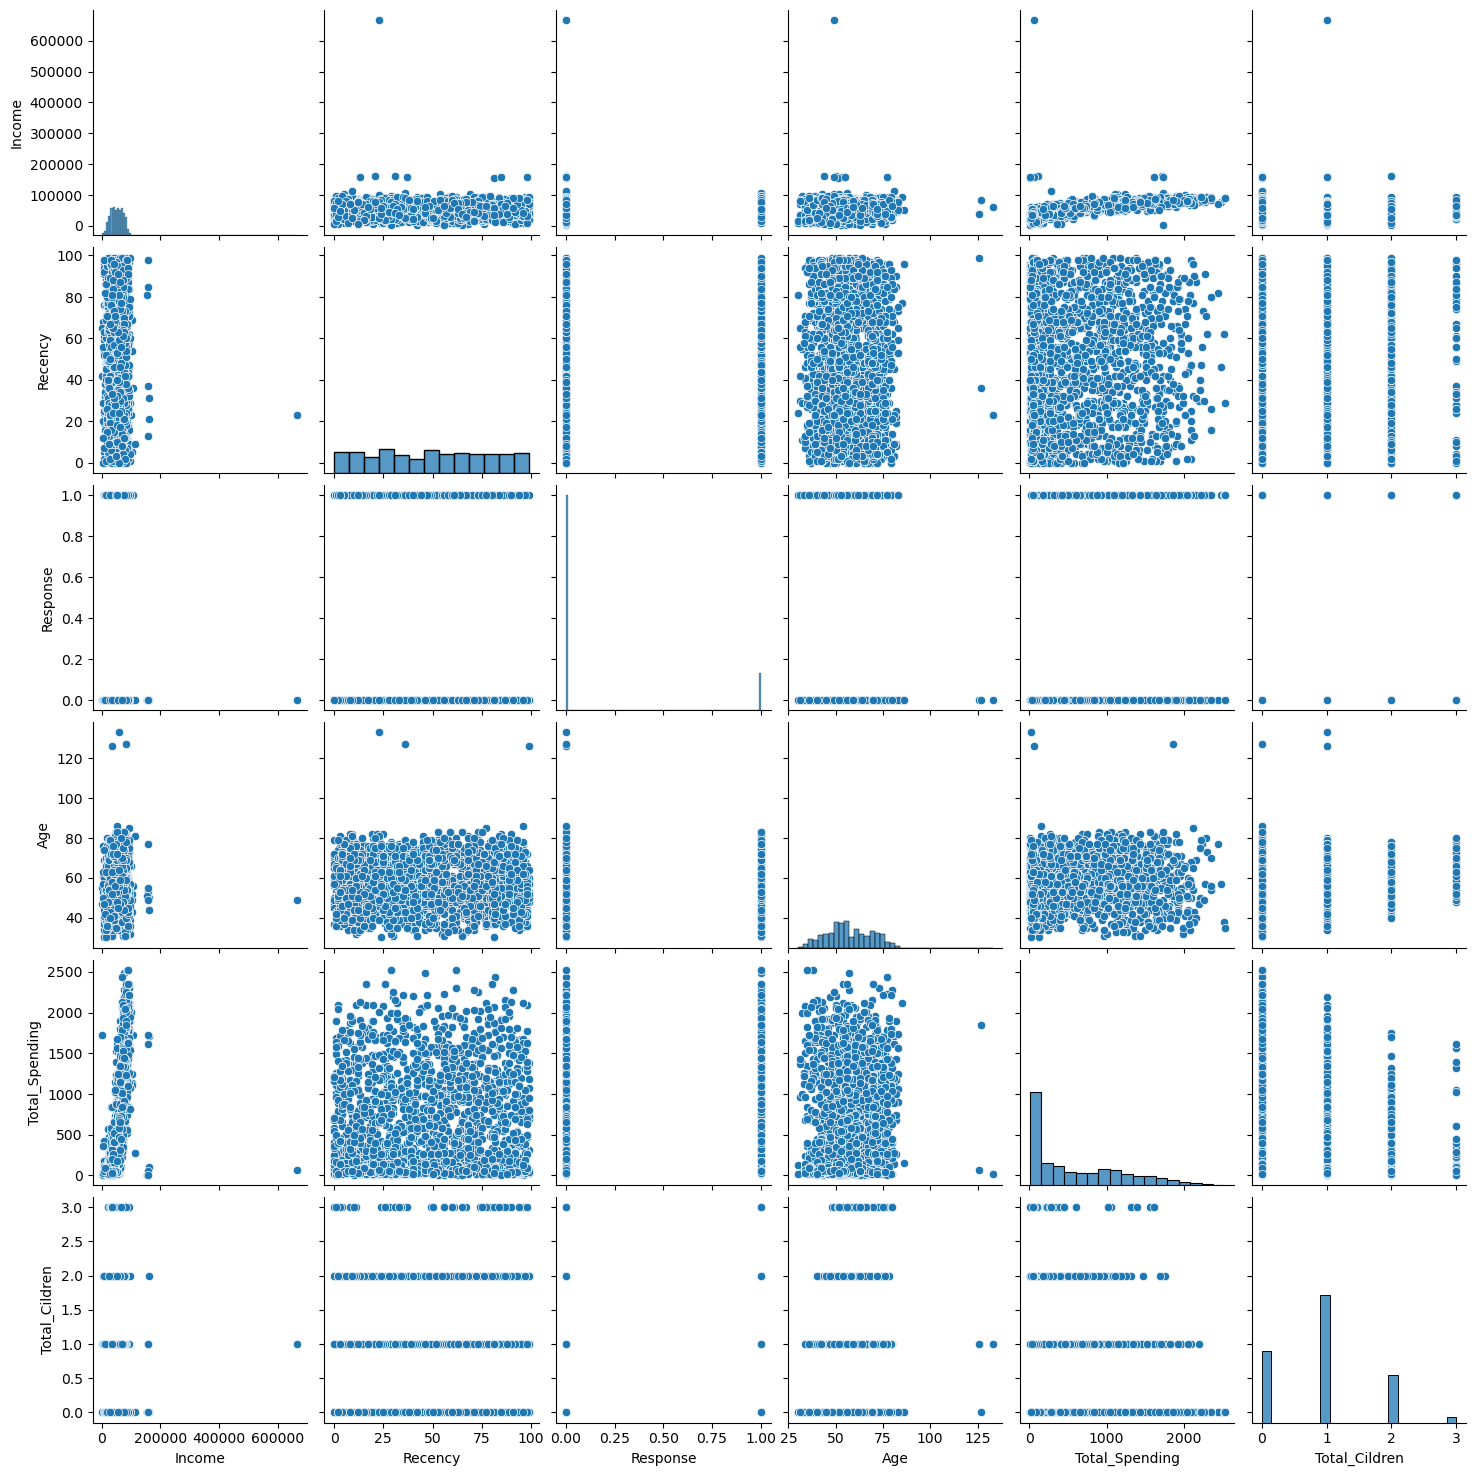

In [20]:
cols = ["Income","Recency","Response","Age","Total_Spending","Total_Cildren"]

import seaborn as sns 
sns.pairplot(df_cleaned[cols])

# By visualising the below figure we get to know that there are only Outlier present 
# in income column and  age column We're income greater than 60,000 And age is greater than 90

In [21]:
print("data size with outlier" ,len(df_cleaned))
df_cleaned = df_cleaned[ (df_cleaned["Income"] < 600_000) ]
df_cleaned = df_cleaned[ (df_cleaned["Age"] < 90 ) ]
print("data size witho outlier" ,len(df_cleaned))

# Show all four columns has been removed from the data frame which were outliers

data size with outlier 2240
data size witho outlier 2236


# Correlation with each other using Heatmap

<Axes: >

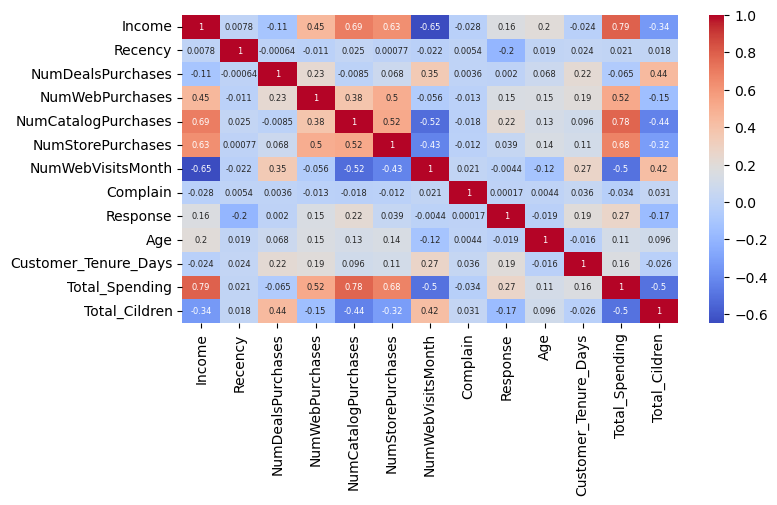

In [22]:
import matplotlib.pyplot as plt
corr = df_cleaned.corr(numeric_only=True)

plt.figure(figsize=(8,4))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)

In [23]:
# Income & Total_Spending → 0.79 (Strong Positive Correlation)
# 👉 Higher income customers spend significantly more.
# This is one of the strongest relationships in the dataset.

# Income & NumCatalogPurchases → 0.69

# Income & NumStorePurchases → 0.63

# Income & NumWebVisitsMonth → -0.65 (Strong Negative)
# 👉 High-income customers visit the website less frequently.

# NumCatalogPurchases & Total_Spending → 0.78 (Very Strong)
# 👉 Catalog purchases contribute heavily to total spending.

# NumStorePurchases & Total_Spending → 0.68

# Encoding

In [24]:
df_cleaned

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Cildren,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,Graduate,61223.0,46,2,9,3,4,5,0,0,59,381,1341,1,Partner
2236,Postgraduate,64014.0,56,7,8,2,5,7,0,0,80,19,444,3,Partner
2237,Graduate,56981.0,91,1,2,3,13,6,0,0,45,155,1241,0,Alone
2238,Postgraduate,69245.0,8,2,6,5,10,3,0,0,70,156,843,1,Partner


In [25]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()

cat_cols = ["Education" , "Living_With"]
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])


In [26]:
enc_cols

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4472 stored elements and shape (2236, 5)>

In [27]:
enc_df = pd.DataFrame(enc_cols.toarray() , columns=ohe.get_feature_names_out(cat_cols) , index=df_cleaned.index)

In [28]:
enc_df

,Education_Graduate,Education_Postgraduate,Education_Undergradute,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...
2235,1.0,0.0,0.0,0.0,1.0
2236,0.0,1.0,0.0,0.0,1.0
2237,1.0,0.0,0.0,1.0,0.0
2238,0.0,1.0,0.0,0.0,1.0


In [29]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols) , enc_df] , axis=1)
df_encoded

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Cildren,Education_Graduate,Education_Postgraduate,Education_Undergradute,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,46,2,9,3,4,5,0,0,59,381,1341,1,1.0,0.0,0.0,0.0,1.0
2236,64014.0,56,7,8,2,5,7,0,0,80,19,444,3,0.0,1.0,0.0,0.0,1.0
2237,56981.0,91,1,2,3,13,6,0,0,45,155,1241,0,1.0,0.0,0.0,1.0,0.0
2238,69245.0,8,2,6,5,10,3,0,0,70,156,843,1,0.0,1.0,0.0,0.0,1.0


# Scaling 

In [30]:
from sklearn.preprocessing import StandardScaler

X = df_encoded

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [31]:
X_scaled

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]], shape=(2236, 18))

# Visualization

In [32]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [33]:
pca.explained_variance_ratio_

# Since here total variance = 0.23 + 0.11 = 0.34 i.e 34% of 100% so we are loosing a lot of data so increase n_componets 

array([0.23163158, 0.11385454])

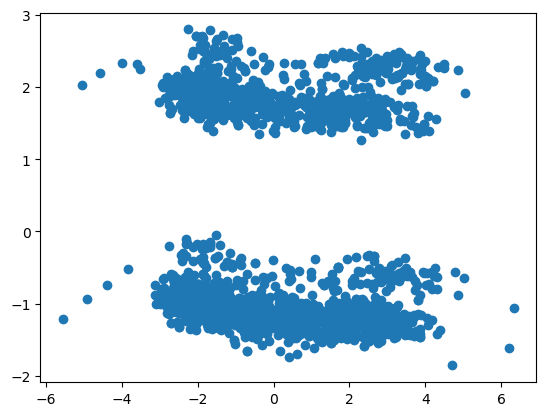

In [34]:
plt.scatter(x=X_pca[:,0] , y=X_pca[:,1])

In [35]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

In [36]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

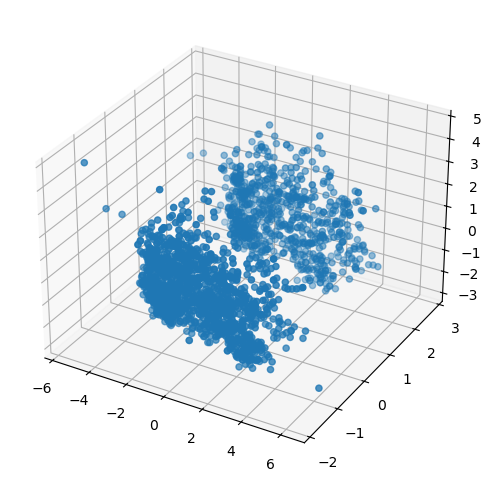

In [37]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection="3d")
# 111 = (1,1,1) Meaning: "Create only one graph in this figure."
# projection="3d" ---> Normally plots are 2D (x and y).But this tells matplotlib: "I want a 3D plot (x, y, z)."

ax.scatter(X_pca[:,0] , X_pca[:,1], X_pca[:,2])

# Analyze K value 
## 1. k-elbow method 

In [38]:
from sklearn.cluster import KMeans 
wcss = []
for k in range(1,11): 
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [39]:
from kneed import KneeLocator

knee = KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
k = knee.elbow
print("best k = ",k)

best k =  4


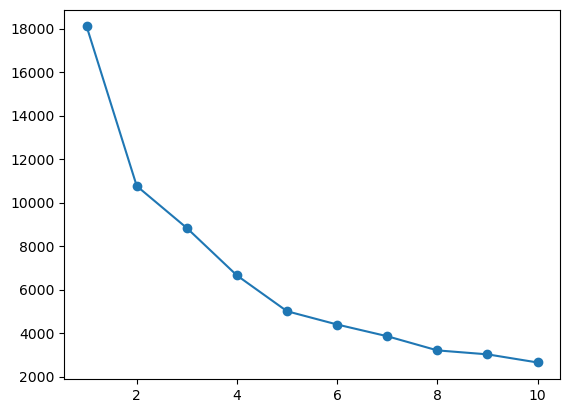

In [40]:
plt.plot(range(1,11),wcss,marker="o")

## 2. Silhoute score 

In [41]:
from sklearn.metrics import silhouette_score  
scores = []
for k in range(2,11): 
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca,labels)
    scores.append(score)

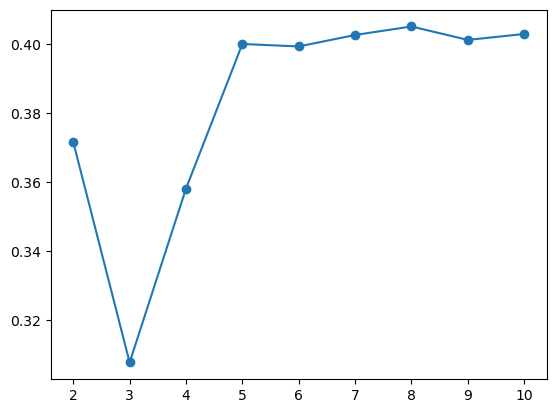

In [42]:
plt.plot(range(2,11),scores,marker="o")

# here the maximum value of k is 8 but it is not optimal but actually the best value of k is the 
# nearest value which intersect both wcss and score plot  
# generally we get the intersection near the k value using elbow methed 

In [43]:
wcss

[18093.257793324552,
 10760.843401758237,
 8830.288717243058,
 6650.96941765888,
 5006.1611680012,
 4396.308699108108,
 3857.6330644275686,
 3207.0576242216507,
 3025.223255432574,
 2651.442989106139]

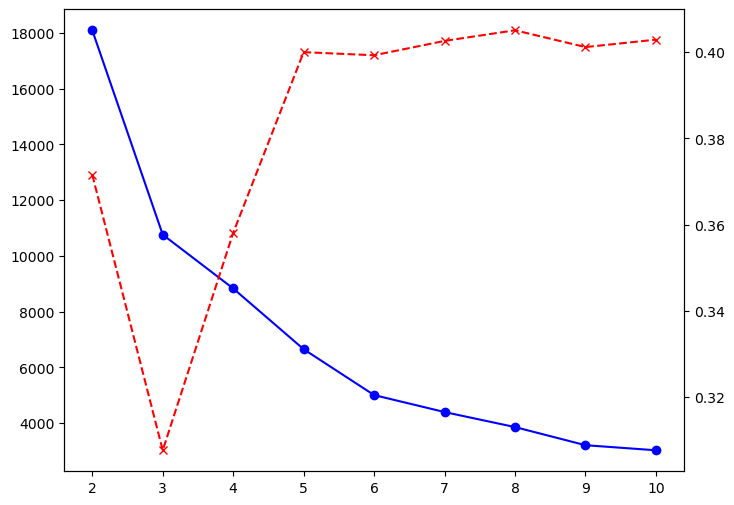

In [44]:
# combined plot : 
k_range = range(2,11)
fig , ax1 = plt.subplots(figsize=(8,6))  # ax1 → first Y-axis graph

ax1.plot(k_range , wcss[:len(k_range)] , marker="o" , color="blue")

ax2 = ax1.twinx()  # Create a second Y-axis that shares the SAME X-axis.
ax2.plot(k_range , scores[:len(k_range)] , marker="x" , color="red" , linestyle="--")

# hence here the intersection point is nearer ro 4 we can conclude that k=4

# Clusting Algorithms 
## 1. KMeans

In [45]:
kmeans = KMeans(n_clusters=4,random_state=42)
labels = kmeans.fit_predict(X_pca)

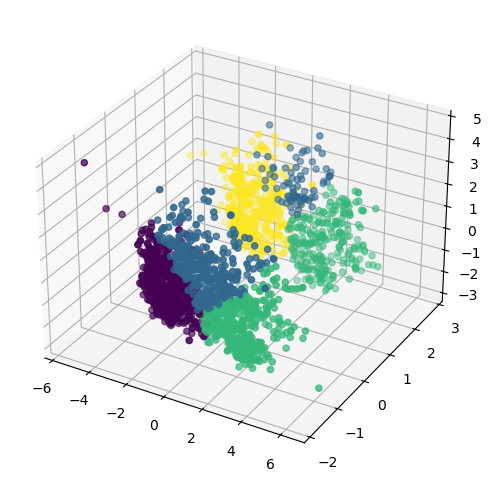

In [46]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection="3d")
# 111 = (1,1,1) Meaning: "Create only one graph in this figure."
# projection="3d" ---> Normally plots are 2D (x and y).But this tells matplotlib: "I want a 3D plot (x, y, z)."

ax.scatter(X_pca[:,0] , X_pca[:,1], X_pca[:,2],c=labels)

## 2. Agglomative Clustering 

In [47]:
from sklearn.cluster import AgglomerativeClustering 

agg = AgglomerativeClustering(n_clusters=4 , linkage="ward")
labels_agg = agg.fit_predict(X_pca)

# | Linkage  | What It Looks At                     |
# | -------- | ------------------------------------ |
# | single   | Closest points                       |
# | complete | Farthest points                      |
# | average  | Average distance                     |
# | ward     | Variance (best for compact clusters) |


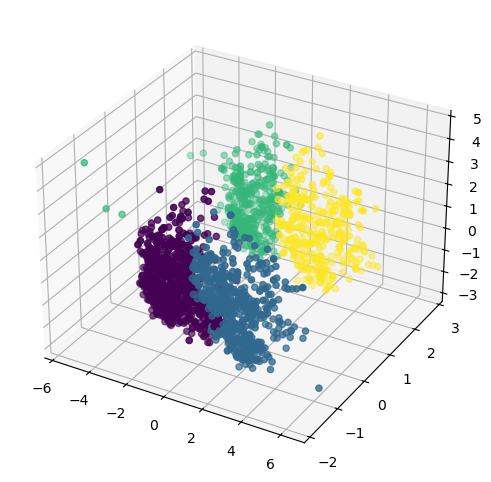

In [48]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection="3d")
# 111 = (1,1,1) Meaning: "Create only one graph in this figure."
# projection="3d" ---> Normally plots are 2D (x and y).But this tells matplotlib: "I want a 3D plot (x, y, z)."

ax.scatter(X_pca[:,0] , X_pca[:,1], X_pca[:,2],c=labels_agg)

# these is better clusterring then KMeans as u can see below 

# Note : we have not used here DBSCAN because it gives 30+ clusters hence now we will go forward with AgglomerativeClustering

## Charectesictic or behavior of clusters which are formed

In [59]:
X["cluster"] = labels_agg 

In [60]:
X

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Cildren,Education_Graduate,Education_Postgraduate,Education_Undergradute,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,46,2,9,3,4,5,0,0,59,381,1341,1,1.0,0.0,0.0,0.0,1.0,0
2236,64014.0,56,7,8,2,5,7,0,0,80,19,444,3,0.0,1.0,0.0,0.0,1.0,0
2237,56981.0,91,1,2,3,13,6,0,0,45,155,1241,0,1.0,0.0,0.0,1.0,0.0,3
2238,69245.0,8,2,6,5,10,3,0,0,70,156,843,1,0.0,1.0,0.0,0.0,1.0,1


<Axes: xlabel='cluster', ylabel='count'>

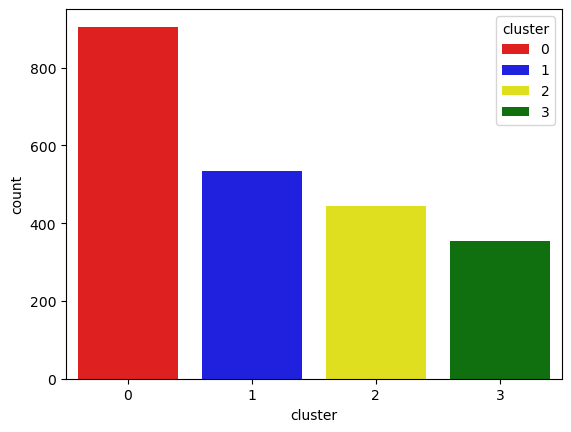

In [61]:
col_palette = ["red","blue","yellow","green"]

sns.countplot(x=X["cluster"] , palette = col_palette , hue=X["cluster"] )

# So majority of the customer lies in the cluster 0

<Axes: xlabel='Total_Spending', ylabel='Income'>

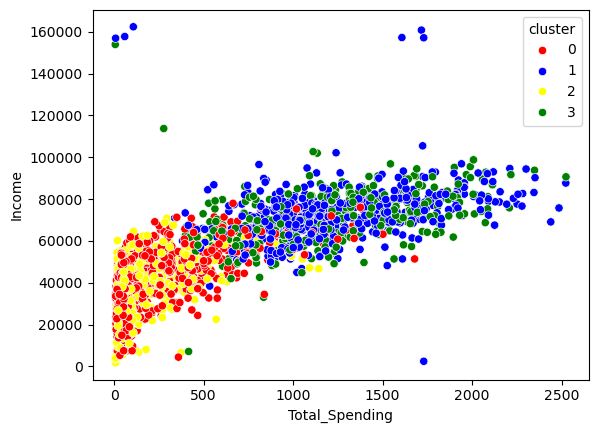

In [62]:
# From the previous heat map we analyze that the income versus total spending has really a greater positive Correlation
# Hence we will look further the characteristics of clusters over this particular feature

sns.scatterplot(x=X["Total_Spending"] , y=X["Income"] , hue = X["cluster"] , palette = col_palette)

# So from the below scatter plot we observe the following patterns or characteristics: 
# Cluster 0 : RED
# Low / Moderate Income
# Low / Moderate Spending

# Cluster 1 : BLUE
# High Income
# High Spending

# Cluster 2 : Yellow
# Low Income
# Low Spend

# Cluster 3 : GREEN
# Moderate-High Income
# High Spend

In [65]:
cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
cluster         

In [ ]:
# | **Cluster 0 (C0) – Family Shoppers**   | **Cluster 1 (C1)  ** |
# | -------------------------------------- | ----------------------------------------------------- |
# | • More children                        | • Fewer children                                      |
# | • Poor campaign response               | • Slightly higher age                                 |
# | • Mostly partners                      | • Average response                                    |
# | • Web visits ↑                         | • Mostly partners                                     |
# | • Web, Catalog, Store ↓                | • Web ↓                                               |
# | • Target Strategy: Discounts & Coupons | • Store & Catalog ↑                                   |
# |                                        | • Target Strategy: Loyalty Programs                   |

# | **Cluster 2 (C2) – Digital Browsers**       | **Cluster 3 (C3) – High Value / Best ROI** |
# | ------------------------------------------- | ------------------------------------------ |
# | • More children                             | • Fewer children                           |
# | • Average campaign response                 | • Slightly higher age                      |
# | • Mostly alone                              | • Best campaign response                   |
# | • Web visits ↑                              | • Mostly single                            |
# | • Web ↓                                     | • Web ↓                                    |
# | • Catalog ↓                                 | • Store & Catalog ↑                        |
# | • Store ↓                                   | • High value customers                     |
# | • Target Strategy: Sales & Discount Coupons | • Target Strategy: Premium Services        |



# Business Insights

# C0 → Family-oriented shoppers, need heavy discounts .

# C1 → would respond well after loyalty programs.

# C2 → Digital browsers, require strong online offers to increase conversion.

# C3 → Best ROI segment, high-value customers, suitable for premium services.